# Parte B (S4) · Dónde invertir para retener clientes — CONECTA S.A., Grupo #1

**Curso:** Visualización de Datos y Gerencia de la Información (UNAULA)

**Integrantes:** Maria Camila Grajales Perez, Stiware Alexander Quintero Aguirre, Juan Pablo Ramirez Gomez

**Grupo:** _#1_

## Propósito

Este notebook retoma el `dataset_limpio.csv` generado en la **Parte A** de `v0.1_s3_dataviz_grupo1.ipynb`
(diagnóstico y limpieza: nulos, VIF, duplicados, texto inconsistente, outliers, coordenadas) y resuelve la
**Parte B**: un hallazgo verificado con variables adicionales, su SCQA, y una primera versión de gráfico
efectivo — esta vez llevando el análisis un nivel más profundo que el ejercicio de `region x plan_type` del
notebook original, hasta el nivel de **ciudad → tier de localidad → motivo de churn** dentro de la región
Caribe, que es donde se concentra la mayor pérdida de ingresos de la compañía.

**Pregunta de negocio:** ¿en qué grupo de usuarios de CONECTA conviene invertir dinero para mejorar la calidad
del servicio, de forma que el impacto en retención (y en ingresos) sea el mayor posible?

## 0. Configuración

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Paleta consistente con el resto del taller (v0.1_s2 / v0.1_s3):
# azules para "servicio estándar", un acento naranja reservado para la
# categoría que concentra el riesgo (tier Baja), gris neutro para lo que
# NO es foco de esta recomendación (tier Alta).
PALETA_TIER = {
    "Alta": "#A9B8C4",   # neutro: estable, no es el foco de esta Parte B
    "Media": "#3A51A3",  # azul fuerte: mayor pérdida absoluta de ingresos
    "Baja": "#D9784F",   # acento cálido: mayor tasa de churn, causa concentrada
}
AZUL_OSCURO = "#132441"
AZUL_CLARO = "#87BBD7"


def formato_cop(valor):
    # COP con separador de miles ".", igual a la convención usada en la exploración previa
    return f"${valor:,.0f}".replace(",", ".")

In [2]:
def normalizar_texto(valor):
    texto = str(valor).strip().upper()
    for con_tilde, sin_tilde in [("Á", "A"), ("É", "E"), ("Í", "I"), ("Ó", "O"), ("Ú", "U")]:
        texto = texto.replace(con_tilde, sin_tilde)
    return texto.title()

## Cargar el insumo de la Parte A

`dataset_limpio.csv` es el entregable de la Parte A. Al inspeccionarlo aquí encontramos que `region` todavía
trae variantes de tildes y espacios (`'Caribe '`, `'Pacífica'`, `'Orinoquía'`...): la celda A10 del notebook
original guardó `df_limpio` a partir de una copia de `df` que no había pasado por la normalización de A5 en
el momento de ejecutarse. No es un problema nuevo de esta Parte B, es el mismo tipo de inconsistencia
diagnosticado en A5 — simplemente falta aplicarla antes de agrupar. La resolvemos aquí con la misma función
`normalizar_texto()` para no arrastrar el error al análisis.

In [3]:
df = pd.read_csv(os.path.join("", "dataset_limpio.csv"))

print("Valores de 'region' antes de normalizar:", sorted(df["region"].unique()))

df["region"] = df["region"].apply(normalizar_texto)
df["plan_type"] = df["plan_type"].apply(normalizar_texto)

print("Valores de 'region' después de normalizar:", sorted(df["region"].unique()))
df.head()

Valores de 'region' antes de normalizar: ['Amazonia ', 'Amazonía', 'Andina', 'Andina ', 'Caribe', 'Caribe ', 'Orinoquia ', 'Orinoquía', 'Pacifica ', 'Pacífica']


Valores de 'region' después de normalizar: ['Amazonia', 'Andina', 'Caribe', 'Orinoquia', 'Pacifica']


,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,"97,400.00",26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,"77,200.00",10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,"59,600.00",2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,"27,700.00",6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,"24,700.00",7.20,1,27.60,1,Competencia,2026-04-18


### Nota de calidad de datos: `localidad` no son barrios reales de cada ciudad

Al preparar el mapa de Barranquilla (más abajo, B3) nos encontramos con que sus localidades se llaman
"Chapinero", "Suba" y "Buenos Aires" — nombres que cualquiera reconoce como barrios de Bogotá, no de
Barranquilla. Lo verificamos con los datos: **no es un error de la limpieza de la Parte A**, ya viene así en
`conecta_sa_grupo1.csv` original. `localidad` se arma con un fondo compartido de solo 40 nombres de barrios
(muchos tomados de Bogotá, Medellín y Cali) que el generador del dataset reparte entre las 25 ciudades como
una **etiqueta de segmento interno**, no como un barrio geográfico real. Dentro de cada ciudad sí es
consistente — cada `localidad` mapea 1 a 1 a un solo `tier_localidad`, nunca se cruza — así que no invalida
ninguno de los números ya calculados (que dependen de `tier_localidad`, no del nombre de `localidad`). Pero
si se toma el nombre literalmente en un mapa puede leerse como un error. Lo confirmamos abajo y lo tenemos en
cuenta en el diseño del Gráfico 1: el tier queda como protagonista de la etiqueta y `localidad` se muestra
como lo que es, un código de segmento, no un barrio real.

In [4]:
# Confirmar el alcance del hallazgo: ¿cuántos nombres de localidad hay en total, y se repiten entre tiers
# de una misma ciudad? (si se repitieran, sí afectaría los números de tier_localidad)
print("Nombres de localidad distintos en todo el dataset:", df["localidad"].nunique(), "para", df["ciudad"].nunique(), "ciudades")

cruce_localidad_tier = df.groupby(["ciudad", "localidad"])["tier_localidad"].nunique()
print("Localidades que aparecen en más de un tier dentro de la misma ciudad:", (cruce_localidad_tier > 1).sum())

print("\nLocalidades de Barranquilla y su tier:")
print(df[df["ciudad"] == "Barranquilla"].groupby("localidad")["tier_localidad"].unique())

Nombres de localidad distintos en todo el dataset: 40 para 25 ciudades
Localidades que aparecen en más de un tier dentro de la misma ciudad: 0

Localidades de Barranquilla y su tier:
localidad
Buenos Aires    [Media]
Chapinero        [Alta]
Suba            [Media]
Zona Norte       [Baja]
Name: tier_localidad, dtype: object


Confirmado: 40 nombres para 25 ciudades, ninguno se cruza de tier dentro de una misma ciudad. Los 4 nombres
de Barranquilla (Chapinero→Alta, Suba y Buenos Aires→Media, Zona Norte→Baja) son solo la etiqueta que le tocó
a cada segmento en este dataset sintético — no hay forma de recuperar los nombres reales de los barrios de
Barranquilla porque esa información nunca estuvo en los datos, e inventarla sería peor que no tenerla. En vez
de dejar el nombre prestado de Bogotá y solo advertirlo con un asterisco, lo reemplazamos por una etiqueta
neutra: `zona` — un número de zona asignado por ciudad, ordenado primero por tier (Alta → Media → Baja) y
luego alfabéticamente por `localidad`, para que la numeración sea reproducible y no dependa del orden de
llegada de las filas.

In [5]:
# Reemplazar 'localidad' por una etiqueta neutra 'zona' (Zona 1, Zona 2, ...) por ciudad,
# para no sugerir que son barrios reales de la ciudad a la que están asignados.
orden_tier = {"Alta": 0, "Media": 1, "Baja": 2}

mapa_zonas = (
    df[["ciudad", "localidad", "tier_localidad"]]
    .drop_duplicates()
    .assign(orden_tier=lambda d: d["tier_localidad"].map(orden_tier))
    .sort_values(["ciudad", "orden_tier", "localidad"])
)
mapa_zonas["zona"] = (
    mapa_zonas.groupby("ciudad").cumcount().add(1).apply(lambda n: f"Zona {n}")
)

df = df.merge(mapa_zonas[["ciudad", "localidad", "zona"]], on=["ciudad", "localidad"], how="left")

print("Zonas de Barranquilla:")
print(
    df[df["ciudad"] == "Barranquilla"]
    .drop_duplicates(subset=["localidad"])[["zona", "localidad", "tier_localidad"]]
    .sort_values("zona")
    .to_string(index=False)
)

Zonas de Barranquilla:


  zona    localidad tier_localidad
Zona 1    Chapinero           Alta
Zona 2 Buenos Aires          Media
Zona 3         Suba          Media
Zona 4   Zona Norte           Baja


De aquí en adelante, cualquier gráfico o tabla que necesite nombrar un segmento geográfico usa `zona`
(Zona 1 a Zona 4 en Barranquilla) en vez de `localidad`. La columna `localidad` original se conserva en el
DataFrame por si se necesita trazabilidad hacia el dato crudo, pero no se vuelve a mostrar en texto ni en
gráficos para no repetir el problema.

**Exportar para Power BI:** el tablero que se va a construir sobre este hallazgo necesita el dataset con
`zona` ya incluida, no solo el cálculo en memoria de este notebook. Se guarda `region` y `plan_type` ya
normalizados (no los valores con tildes/espacios sueltos de `dataset_limpio.csv`) y la columna `zona`
calculada arriba, para que el modelo de Power BI no tenga que repetir esa limpieza. El resultado son las
mismas 453.803 filas y todas las columnas originales de `dataset_limpio.csv`, más `zona` al final.

In [6]:
ruta_salida = "dataset_limpio_con_zonas.csv"
df.to_csv(ruta_salida, index=False)

print(
    f"Guardado '{ruta_salida}': {len(df):,} filas, {df.shape[1]} columnas".replace(",", ".")
)
print("Columnas:", list(df.columns))

Guardado 'dataset_limpio_con_zonas.csv': 453.803 filas. 21 columnas
Columnas: ['user_id', 'mes', 'pais', 'region', 'ciudad', 'localidad', 'tier_localidad', 'latitud', 'longitud', 'plan_type', 'signup_date', 'tenure_months', 'es_cliente_nuevo_mes', 'monthly_revenue_cop', 'data_usage_gb', 'complaints_month', 'nps_score', 'churned', 'churn_type', 'churn_date', 'zona']


## B1. Hallazgo y verificación

**Punto de partida (Parte A / hallazgo ya reportado en `v0.1_s3`):** la región Caribe tiene la tasa de churn
más alta del país (10,19%), muy por encima de Andina (0,93%). Antes de convertir eso en una recomendación de
inversión necesitamos saber si ese 10,19% son ingresos que realmente importan en pesos, y dónde adentro del
Caribe se concentran — región, ciudad y tier de localidad.

In [7]:
# Paso 1: cuantificar el hallazgo de la región en pesos, no solo en tasa de churn
perdida_total_compania = df.loc[df["churned"] == 1, "monthly_revenue_cop"].sum()

resumen_region = df.groupby("region").agg(
    usuarios=("user_id", "count"),
    churners=("churned", "sum"),
    ingresos_perdidos=(
        "monthly_revenue_cop",
        lambda x: x[df.loc[x.index, "churned"] == 1].sum(),
    ),
)
resumen_region["churn_rate_pct"] = resumen_region["churners"] / resumen_region["usuarios"] * 100
resumen_region["user_share_pct"] = resumen_region["usuarios"] / resumen_region["usuarios"].sum() * 100
resumen_region["loss_share_pct"] = resumen_region["ingresos_perdidos"] / perdida_total_compania * 100

print(f"Pérdida de ingresos de toda la compañía en 3 meses: {formato_cop(perdida_total_compania)}")
resumen_region.sort_values("ingresos_perdidos", ascending=False)

Pérdida de ingresos de toda la compañía en 3 meses: $800.116.100


,usuarios,churners,ingresos_perdidos,churn_rate_pct,user_share_pct,loss_share_pct
region,,,,,,
Caribe,79269,8079,"470,764,800.00",10.19,17.47,58.84
Andina,273614,2535,"171,498,500.00",0.93,60.29,21.43
Pacifica,72201,1633,"99,331,800.00",2.26,15.91,12.41
Orinoquia,20399,617,"37,126,000.00",3.02,4.50,4.64
Amazonia,8320,363,"21,395,000.00",4.36,1.83,2.67


**En pesos, la desproporción es mayor de lo que sugiere la tasa de churn sola:** el Caribe tiene el 17,5% de
los usuarios de CONECTA pero concentra el 58,8% de toda la pérdida de ingresos por churn de la compañía en
estos 3 meses. Con esto confirmado en dinero (no solo en tasa), bajamos un nivel: ¿qué ciudad del Caribe
explica esa concentración?

In [8]:
# Paso 2: dentro de Caribe, por ciudad y por mes (para no confundir un pico de un solo mes con un patrón)
df_caribe = df[df["region"] == "Caribe"].copy()

resumen_ciudad_mes = (
    df_caribe.groupby(["ciudad", "mes"])
    .agg(
        usuarios=("user_id", "count"),
        churners=("churned", "sum"),
        ingresos_perdidos=(
            "monthly_revenue_cop",
            lambda x: x[df_caribe.loc[x.index, "churned"] == 1].sum(),
        ),
    )
    .reset_index()
)
resumen_ciudad_mes["user_share_pct"] = (
    resumen_ciudad_mes["usuarios"] / resumen_ciudad_mes.groupby("mes")["usuarios"].transform("sum") * 100
)
resumen_ciudad_mes["loss_share_pct"] = (
    resumen_ciudad_mes["ingresos_perdidos"]
    / resumen_ciudad_mes.groupby("mes")["ingresos_perdidos"].transform("sum")
    * 100
)

resumen_ciudad_mes.sort_values(["mes", "loss_share_pct"], ascending=[True, False])

,ciudad,mes,usuarios,churners,ingresos_perdidos,user_share_pct,loss_share_pct
0,Barranquilla,2026-03,9955,1023,"60,032,400.00",35.12,36.44
3,Cartagena,2026-03,7871,797,"46,568,700.00",27.77,28.27
9,Santa Marta,2026-03,4602,469,"26,841,400.00",16.24,16.29
6,Montería,2026-03,3330,320,"17,710,500.00",11.75,10.75
12,Valledupar,2026-03,2584,250,"13,595,700.00",9.12,8.25
1,Barranquilla,2026-04,9246,891,"54,123,600.00",35.06,35.81
4,Cartagena,2026-04,7311,742,"42,225,300.00",27.72,27.94
10,Santa Marta,2026-04,4284,437,"24,501,200.00",16.24,16.21
7,Montería,2026-04,3126,306,"16,764,200.00",11.85,11.09
13,Valledupar,2026-04,2405,240,"13,526,000.00",9.12,8.95


**Barranquilla no es un pico de un mes:** en los tres meses disponibles (marzo, abril, mayo de 2026) es
sistemáticamente la ciudad con más usuarios (~35%), más churners y mayor pérdida de ingresos (35-36%) de
la región Caribe — por encima de Cartagena, que es la segunda ciudad en todas las métricas y todos los
meses. El patrón se sostiene mes a mes, así que seguimos bajando de nivel: dentro de Barranquilla, ¿todos
los tiers de servicio pesan igual?

In [9]:
# Paso 3: dentro de Barranquilla, por tier de localidad
df_baq = df_caribe[df_caribe["ciudad"] == "Barranquilla"].copy()

resumen_tier = df_baq.groupby("tier_localidad").agg(
    usuarios=("user_id", "count"),
    churners=("churned", "sum"),
    ingresos_perdidos=(
        "monthly_revenue_cop",
        lambda x: x[df_baq.loc[x.index, "churned"] == 1].sum(),
    ),
)
resumen_tier["churn_rate_pct"] = resumen_tier["churners"] / resumen_tier["usuarios"] * 100
resumen_tier["user_share_pct"] = resumen_tier["usuarios"] / resumen_tier["usuarios"].sum() * 100
resumen_tier["churn_share_pct"] = resumen_tier["churners"] / resumen_tier["churners"].sum() * 100
resumen_tier["loss_share_pct"] = resumen_tier["ingresos_perdidos"] / resumen_tier["ingresos_perdidos"].sum() * 100

resumen_tier.sort_values("ingresos_perdidos", ascending=False)

,usuarios,churners,ingresos_perdidos,churn_rate_pct,user_share_pct,churn_share_pct,loss_share_pct
tier_localidad,,,,,,,
Media,15869,1547,"88,950,700.00",9.75,56.99,54.59,53.88
Baja,4457,758,"44,710,600.00",17.01,16.01,26.75,27.08
Alta,7519,529,"31,424,700.00",7.04,27.00,18.67,19.04


Dos historias distintas conviven en Barranquilla:

- **Tier Media** (15.869 usuarios, el más grande) genera el **53,9% de la pérdida de ingresos de la ciudad**
  ($88,95 M) simplemente por volumen — su tasa de churn (9,75%) es la más baja de las tres.
- **Tier Baja** (4.457 usuarios, el más pequeño) tiene la **tasa de churn más alta de la ciudad (17,01%)**,
  casi el doble que Media, y aun siendo un tercio del tamaño de Media genera el 27,1% de la pérdida
  ($44,71 M).

Antes de recomendar dónde invertir falta la pregunta de mecanismo: ¿el churn en Media y en Baja pasa por el
mismo motivo, o son problemas distintos que necesitan remedios distintos?

In [10]:
# Paso 4: mecanismo — motivo de churn (churn_type) dentro de cada tier
motivos_tier = (
    df_baq[df_baq["churned"] == 1]
    .groupby(["tier_localidad", "churn_type"])
    .size()
    .reset_index(name="churners")
)
motivos_tier["motivo_share_pct"] = (
    motivos_tier["churners"] / motivos_tier.groupby("tier_localidad")["churners"].transform("sum") * 100
)

motivos_tier[motivos_tier["tier_localidad"].isin(["Media", "Baja"])].sort_values(
    ["tier_localidad", "motivo_share_pct"], ascending=[True, False]
)

,tier_localidad,churn_type,churners,motivo_share_pct
8,Baja,Red,351,46.31
9,Baja,Servicio al cliente,152,20.05
7,Baja,Precio,120,15.83
5,Baja,Competencia,78,10.29
6,Baja,Otro,57,7.52
13,Media,Red,505,32.64
14,Media,Servicio al cliente,329,21.27
10,Media,Competencia,297,19.20
12,Media,Precio,262,16.94
11,Media,Otro,154,9.95


**El mecanismo no es el mismo:** en el tier Baja, el 46,3% de las bajas son por **Red** — casi 1 de cada 2 —
un problema muy concentrado y, en principio, más barato de intervenir con una sola causa raíz. En el tier
Media el motivo también es Red (32,6%), pero mucho más repartido con Servicio al cliente (21,3%),
Competencia (19,2%) y Precio (16,9%): un problema más diversificado, donde arreglar solo la red deja buena
parte del churn sin resolver.

In [11]:
# Paso 5: estabilidad — ¿el patrón de churn por tier se sostiene los 3 meses, o es ruido de uno solo?
resumen_tier_mes = (
    df_baq.groupby(["mes", "tier_localidad"])
    .agg(usuarios=("user_id", "count"), churners=("churned", "sum"))
    .reset_index()
)
resumen_tier_mes["churn_rate_pct"] = resumen_tier_mes["churners"] / resumen_tier_mes["usuarios"] * 100

resumen_tier_mes.pivot(index="mes", columns="tier_localidad", values="churn_rate_pct")

tier_localidad,Alta,Baja,Media
mes,,,
2026-03,7.45,15.34,10.00
2026-04,6.21,16.85,9.24
2026-05,7.44,19.50,10.01


El tier Baja no solo tiene la tasa más alta de los tres: **está empeorando mes a mes** (15,3% → 16,8% →
19,5%), mientras que Media y Alta se mantienen estables en su rango. Esto refuerza la urgencia relativa de
Baja frente a Media, aunque Media siga siendo mayor en pesos absolutos.

In [12]:
# Paso 6: confusores obvios — ¿la diferencia entre tiers es en realidad por tipo de plan o por ingreso
# promedio del usuario, y no por el tier en sí?
control_confusores = df_baq.groupby("tier_localidad").agg(
    ingreso_prom_usuario=("monthly_revenue_cop", "mean"),
    consumo_datos_prom=("data_usage_gb", "mean"),
    antiguedad_prom_meses=("tenure_months", "mean"),
)
mezcla_plan_pct = pd.crosstab(df_baq["tier_localidad"], df_baq["plan_type"], normalize="index") * 100

display(control_confusores)
display(mezcla_plan_pct)

,ingreso_prom_usuario,consumo_datos_prom,antiguedad_prom_meses
tier_localidad,,,
Alta,"58,462.28",10.57,16.84
Baja,"57,769.82",7.66,17.78
Media,"57,920.64",9.63,18.08


plan_type,Convergente,Pospago,Prepago
tier_localidad,,,
Alta,26.25,35.06,38.69
Baja,25.11,34.71,40.18
Media,25.00,36.18,38.81


Ni el ingreso promedio por usuario (~$57.500-$58.500 COP en los tres tiers), ni la mezcla de `plan_type`
(Prepago/Pospago/Convergente en proporciones casi idénticas en los tres tiers, diferencias menores a 2 pp),
explican la diferencia de churn entre Media y Baja. Esto descarta dos confusores obvios y deja al tier de
localidad (y a Red como motivo dominante en Baja) como la variable que sí separa los grupos.

**Su conclusión (hallazgo verificado):** el churn de CONECTA no está distribuido parejo por el país: se
concentra en la región Caribe (58,8% de la pérdida de ingresos con solo 17,5% de los usuarios), dentro del
Caribe en Barranquilla (~35% de usuarios, churners e ingresos perdidos de la región, estable en los 3
meses), y dentro de Barranquilla en dos grupos con problemas distintos: el tier **Media**, que por su
volumen concentra la mayor pérdida absoluta de ingresos de la ciudad ($88,95 M, 53,9%) con un churn
diversificado (Red, Servicio, Competencia y Precio con pesos similares); y el tier **Baja**, más pequeño
pero con la tasa de churn más alta y en aumento (17,01%, subiendo cada mes) y una causa muy concentrada:
Red explica casi la mitad de sus bajas (46,3%). El hallazgo se sostiene al verificarlo con tier_localidad,
churn_type, mes, plan_type y monthly_revenue_cop — no desaparece ni se explica por confusores obvios.

## B2. Escribir el SCQA

**Situación:** el presupuesto de CONECTA para retención y calidad de servicio es limitado y se asigna por
ciclo (el corte de datos disponible es trimestral: marzo-mayo 2026) entre las zonas del país donde opera. En
cada ciclo, el comité tiene que decidir en qué grupo de clientes concentrar ese presupuesto — no puede
repartirlo entre todas las zonas con la misma intensidad — sabiendo que una elección equivocada no solo
desperdicia el ciclo, sino que deja sin atender al grupo que sí lo necesitaba.

**Complicación:** dentro de Barranquilla —ya identificada como la ciudad más golpeada por churn del Caribe—
compiten dos grupos con perfiles opuestos: el tier Media pierde más dinero en total pero por varias causas a
la vez, y el tier Baja pierde menos dinero pero tiene la tasa de churn más alta y concentrada casi toda en un
solo motivo. El presupuesto no alcanza para atacar ambos frentes con la misma fuerza en el mismo ciclo, y
antes de comprometerlo el comité puede objetar, con razón, que el tier Baja no tiene un problema operativo
nuevo sino una desventaja estructural: son zonas de menor tier de servicio, con menor cobertura histórica de
red y clientes con menor disposición de pago, así que la diferencia de churn sería un efecto de composición,
no algo que la inversión pueda revertir. Si esa objeción fuera cierta, poner presupuesto de red en el tier
Baja no bajaría su churn y el ciclo se perdería.

**Pregunta:** ¿el mayor churn del tier Baja en Barranquilla es un problema de red corregible con inversión, o
es un efecto de composición (estrato de servicio, cobertura histórica) que el presupuesto no puede mover? Y
si es corregible, ¿qué zona debe priorizar el comité en este ciclo para minimizar el gasto y garantizar el
mayor retorno en ingresos retenidos?

**Respuesta:** es corregible, no composición — y el orden de prioridad no es el mismo según se mire por tasa
o por pesos. La objeción de composición no se sostiene con la evidencia: el ingreso promedio por usuario
(~$57.500-$58.500 COP) y la mezcla de `plan_type` son prácticamente idénticos entre Alta, Media y Baja
(diferencias menores a 2 puntos porcentuales), así que no hay una base estructural de menor poder adquisitivo
que explique el churn del tier Baja. Lo que sí lo distingue es el motivo que los propios clientes reportan al
irse: 46,3% de las bajas de Baja citan **Red**, casi el doble de concentrado que en Media (32,6%, repartido
con Servicio, Competencia y Precio) — una causa operativa, no demográfica. Tampoco es un efecto fijo de
composición: la tasa de churn de Baja subió cada uno de los 3 meses observados (15,3% → 16,8% → 19,5%),
mientras Alta y Media se mantuvieron estables — una composición fija no se deteriora mes a mes.

En pesos, hoy: Baja son 4.457 usuarios que pierden $44,71 M cada 3 meses (27,1% de la pérdida de
Barranquilla) con un churn que sigue subiendo; Media son 15.869 usuarios que pierden $88,95 M (53,9%) con una
tasa estable pero repartida entre 4 causas de peso similar, lo que hace más cara y menos predecible una única
intervención. Por eso el comité debe priorizar primero la **Zona 4** (tier Baja): es la intervención más
barata de diseñar (una sola causa explica casi la mitad del problema), la más urgente (churn en aumento, no
estable) y la de menor riesgo de gasto sin retorno, precisamente porque la hipótesis de composición queda
descartada con los datos. En paralelo, si el presupuesto del ciclo alcanza para un segundo frente, extender
la misma intervención de Red a las **Zonas 2 y 3** (tier Media) es lo que recupera la mayor cantidad absoluta
de ingresos de la ciudad — con menor retorno por peso invertido que en Baja, porque ahí Red compite con otras
tres causas de peso casi igual.

## B3. Primera versión del gráfico efectivo

**Propósito:** el título es, literalmente, la Respuesta del SCQA. El gráfico principal es un mapa de puntos
enfocado en Barranquilla (mismo tipo de mapa de puntos usado en `v0.1_s2_dataviz_grupo1.ipynb`, sección 5,
pero aquí filtrado a una sola ciudad — que es justo el caso en el que ese notebook concluyó que el detalle
por coordenada exacta sí aporta, en vez de perderse en sobreposición). Lo acompañan dos gráficos de apoyo que
sostienen, respectivamente, el mecanismo (motivo de churn) y la estabilidad (tendencia mensual) detrás de la
recomendación.

**Principios de diseño aplicados en el mapa (Gráfico 1):**
- *Balance dato-contexto:* una capa tenue (alpha bajo) muestra los usuarios individuales como contexto
  geográfico real; una capa de burbujas por zona muestra la magnitud que importa (pérdida en pesos).
- *Tinta proporcional / codificación redundante:* el tamaño de cada burbuja es proporcional a la raíz
  cuadrada de la pérdida de ingresos (no al radio directo, para no exagerar visualmente la diferencia), y el
  color repite la misma categoría (tier) que ya se ve en la posición/agrupación geográfica.
- *Color con propósito, no arcoíris:* solo 3 colores, en orden fijo por tier; gris neutro para Alta (no es
  foco de esta recomendación), azul para Media, y un acento cálido reservado para Baja (el grupo más
  urgente), consistente con el resto del taller.
- *Área focalizada:* los ejes se recortan al bounding box real de Barranquilla, no al de toda Colombia — es
  el caso de uso que el propio equipo identificó en `v0.1_s2` como el único donde el mapa de puntos aporta
  más que el choropleth.
- *Eliminación de desorden:* solo se etiquetan las 4 zonas (una por tier en esta ciudad, dos en Media), no
  cada punto individual, y se usa `zona` (Zona 1-4) en vez del nombre de `localidad`, que resulta ser un
  nombre de barrio prestado de otra ciudad (ver nota de calidad de datos antes de B1) y podía confundir al
  lector.

Coordenadas válidas dentro de Colombia: 27119 de 27845 (97.4%). El resto son nulos o valores fuera de rango pendientes de la imputación completa de la Parte A (A9).


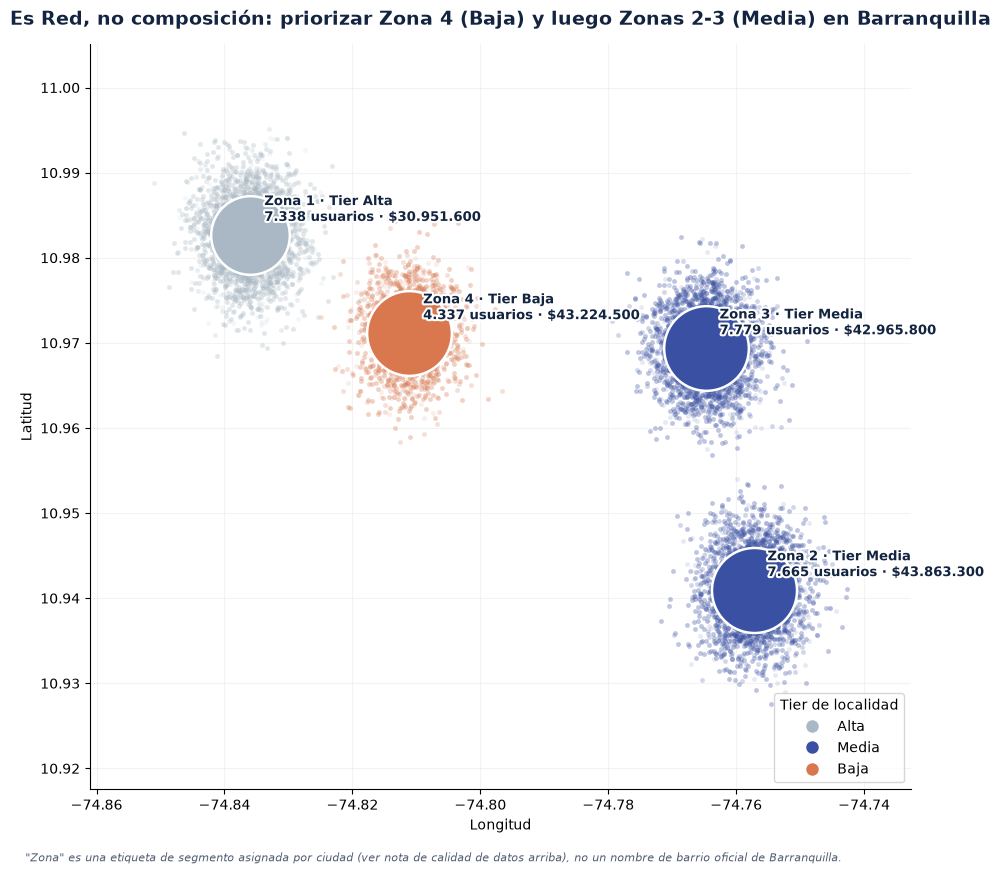

In [13]:
# Gráfico 1 · Mapa enfocado en Barranquilla — magnitud (pérdida de ingresos) y mecanismo (tier) geolocalizados
coords_validas = df_baq["latitud"].between(0, 13) & df_baq["longitud"].between(-80, -66)
df_baq_geo = df_baq[coords_validas].copy()
print(
    f"Coordenadas válidas dentro de Colombia: {coords_validas.sum()} de {len(df_baq)} "
    f"({coords_validas.mean() * 100:.1f}%). El resto son nulos o valores fuera de rango "
    "pendientes de la imputación completa de la Parte A (A9)."
)

zonas = (
    df_baq_geo.groupby(["zona", "tier_localidad"])
    .agg(
        usuarios=("user_id", "count"),
        lat=("latitud", "mean"),
        lon=("longitud", "mean"),
        ingresos_perdidos=(
            "monthly_revenue_cop",
            lambda x: x[df_baq_geo.loc[x.index, "churned"] == 1].sum(),
        ),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 9))

# Capa 1 — contexto: usuarios individuales, tenues, coloreados por tier
for tier, color in PALETA_TIER.items():
    datos = df_baq_geo[df_baq_geo["tier_localidad"] == tier]
    ax.scatter(
        datos["longitud"], datos["latitud"],
        color=color, alpha=0.12, s=12, linewidths=0, zorder=2,
    )

# Capa 2 — magnitud: una burbuja por zona, tamaño = pérdida de ingresos (escala en raíz cuadrada)
tam_max = 3400
for _, fila in zonas.iterrows():
    tam = 350 + tam_max * np.sqrt(fila["ingresos_perdidos"] / zonas["ingresos_perdidos"].max())
    ax.scatter(
        fila["lon"], fila["lat"],
        s=tam, color=PALETA_TIER[fila["tier_localidad"]],
        edgecolor="white", linewidth=1.8, zorder=3,
    )
    ax.annotate(
        f"{fila['zona']} · Tier {fila['tier_localidad']}\n"
        f"{fila['usuarios']:,} usuarios · {formato_cop(fila['ingresos_perdidos'])}".replace(",", "."),
        xy=(fila["lon"], fila["lat"]),
        xytext=(10, 10), textcoords="offset points",
        fontsize=9.5, fontweight="bold", color=AZUL_OSCURO,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
        zorder=4,
    )

# Leyenda manual (color = tier, fijo en el mismo orden que el resto del análisis)
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=10, markerfacecolor=color, markeredgecolor="white")
    for color in PALETA_TIER.values()
]
ax.legend(handles, PALETA_TIER.keys(), title="Tier de localidad", loc="lower right", frameon=True)

# Área focalizada: recorte al bounding box real de Barranquilla, con un margen pequeño
margen = 0.01
ax.set_xlim(df_baq_geo["longitud"].min() - margen, df_baq_geo["longitud"].max() + margen)
ax.set_ylim(df_baq_geo["latitud"].min() - margen, df_baq_geo["latitud"].max() + margen)

ax.set_title(
    "Es Red, no composición: priorizar Zona 4 (Baja) y luego Zonas 2-3 (Media) en Barranquilla",
    fontsize=13.5, fontweight="bold", color=AZUL_OSCURO, pad=14, wrap=True,
)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.grid(alpha=0.15)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.text(
    0.02, 0.01,
    "\"Zona\" es una etiqueta de segmento asignada por ciudad (ver nota de calidad de datos arriba), "
    "no un nombre de barrio oficial de Barranquilla.",
    fontsize=8, color=AZUL_OSCURO, alpha=0.75, style="italic",
)

plt.tight_layout(rect=[0, 0.025, 1, 1])
plt.show()

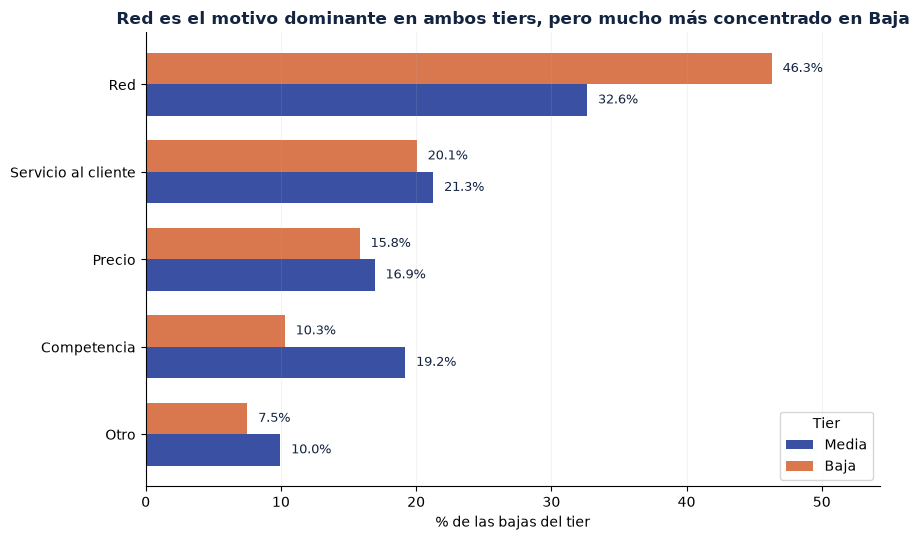

In [14]:
# Gráfico 2 (apoyo) · Mecanismo — motivo de churn dentro de cada tier
orden_motivos = ["Red", "Servicio al cliente", "Precio", "Competencia", "Otro"]
tabla_motivos = motivos_tier[motivos_tier["tier_localidad"].isin(["Media", "Baja"])].pivot(
    index="churn_type", columns="tier_localidad", values="motivo_share_pct"
).reindex(orden_motivos)

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(orden_motivos))
alto = 0.36

ax.barh(y + alto / 2, tabla_motivos["Media"], height=alto, color=PALETA_TIER["Media"], label="Media")
ax.barh(y - alto / 2, tabla_motivos["Baja"], height=alto, color=PALETA_TIER["Baja"], label="Baja")

for yi, (media_val, baja_val) in enumerate(zip(tabla_motivos["Media"], tabla_motivos["Baja"])):
    ax.text(media_val + 0.8, yi + alto / 2, f"{media_val:.1f}%", va="center", fontsize=9, color=AZUL_OSCURO)
    ax.text(baja_val + 0.8, yi - alto / 2, f"{baja_val:.1f}%", va="center", fontsize=9, color=AZUL_OSCURO)

ax.set_yticks(y)
ax.set_yticklabels(orden_motivos)
ax.invert_yaxis()
ax.set_xlabel("% de las bajas del tier")
ax.set_title(
    "Red es el motivo dominante en ambos tiers, pero mucho más concentrado en Baja",
    fontsize=12.5, fontweight="bold", color=AZUL_OSCURO,
)
ax.set_xlim(0, max(tabla_motivos.max()) + 8)
ax.legend(title="Tier", loc="lower right", frameon=True)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)

plt.tight_layout()
plt.show()

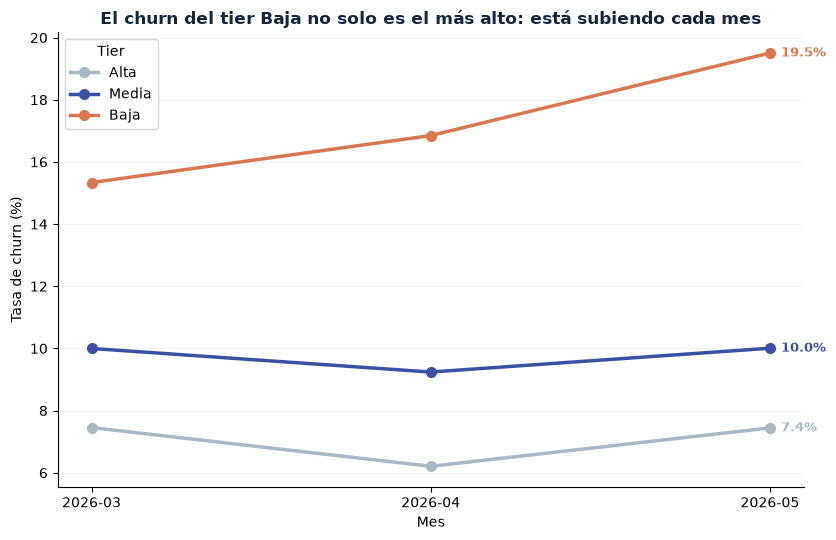

In [15]:
# Gráfico 3 (apoyo) · Estabilidad — tasa de churn por tier, mes a mes
tabla_tier_mes = resumen_tier_mes.pivot(index="mes", columns="tier_localidad", values="churn_rate_pct")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for tier in ["Alta", "Media", "Baja"]:
    ax.plot(
        tabla_tier_mes.index, tabla_tier_mes[tier],
        marker="o", markersize=7, linewidth=2.5, color=PALETA_TIER[tier], label=tier,
    )
    ax.annotate(
        f"{tabla_tier_mes[tier].iloc[-1]:.1f}%",
        xy=(tabla_tier_mes.index[-1], tabla_tier_mes[tier].iloc[-1]),
        xytext=(8, 0), textcoords="offset points",
        va="center", fontsize=9.5, fontweight="bold", color=PALETA_TIER[tier],
    )

ax.set_title(
    "El churn del tier Baja no solo es el más alto: está subiendo cada mes",
    fontsize=12.5, fontweight="bold", color=AZUL_OSCURO,
)
ax.set_ylabel("Tasa de churn (%)")
ax.set_xlabel("Mes")
ax.legend(title="Tier", frameon=True)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

**Su conclusión:** el mapa (Gráfico 1) es el que sostiene la Respuesta del SCQA — muestra en una sola vista
que la Zona 4 (Baja) y las Zonas 2 y 3 (Media) son geográficamente distintas y que las burbujas de Media son
visualmente la mayor pérdida en pesos, mientras que la de Baja, aunque más chica en pesos, corresponde al
tier con la tasa más alta. Los Gráficos 2 y 3 son evidencia de apoyo: el 2 justifica *por qué* Red es la
prioridad de intervención en ambos tiers (más en Baja que en Media), y el 3 justifica *cuándo* — Baja no
puede esperar al siguiente trimestre porque su churn sigue subiendo. Falta por pulir en próximas versiones:
agregar el costo estimado de una intervención de red por zona (no disponible en este dataset) para
convertir la comparación de pérdida evitada en un ROI explícito, y una versión interactiva del mapa que
permita alternar la métrica de color entre tier, motivo de churn y mes.

## Entregable Parte B

El hallazgo verificado (región → ciudad → tier → motivo de churn), el SCQA escrito, y la primera versión del
gráfico efectivo (mapa enfocado en Barranquilla + 2 gráficos de apoyo), con los principios de diseño
aplicados documentados arriba.

## Preguntas de validación del hallazgo

**Magnitud — ¿mi hallazgo está en unidades que el negocio usa (dinero, usuarios), no solo en tasas o
porcentajes?**

Sí. Cada nivel del hallazgo se reporta en pesos y en usuarios, no solo en tasas: el Caribe pierde
$470,8 M de $800,1 M de la compañía en 3 meses (58,8%); Barranquilla concentra $165,1 M de esos $470,8 M;
dentro de Barranquilla, Media pierde $88,95 M (15.869 usuarios) y Baja $44,71 M (4.457 usuarios). Las tasas
(10,19% churn regional, 17,01% en Baja) se usan solo para comparar velocidad relativa entre grupos, nunca
como la única evidencia de impacto — que es justamente lo que el propio equipo señaló como riesgo en la
sección 6 de `v0.1_s2` (una tasa alta sobre un grupo chico puede sonar grave y pesar poco en pesos).

**Mecanismo — ¿tengo evidencia de por qué pasa esto, con las variables que ya exploré en Parte A, o solo
digo que pasa?**

Sí, hasta el nivel de motivo de churn (`churn_type`), que es la variable más cercana a una causa raíz
disponible en el dataset: en Baja el 46,3% de las bajas son por Red (causa única, concentrada); en Media el
motivo también es Red (32,6%) pero repartido con Servicio, Competencia y Precio. Eso es lo que permite
recomendar una intervención específica (red) y no solo "invertir en el tier Baja" sin decir en qué.

**Estabilidad — si tengo datos de varios períodos, ¿verifiqué que el patrón no es ruido de un solo mes?**

Sí, en dos niveles. (1) El liderazgo de Barranquilla dentro del Caribe se repite en los 3 meses disponibles
(marzo-mayo 2026) con una participación estable de usuarios, churners e ingresos perdidos (~35% en los tres
meses). (2) La tasa de churn por tier también se revisó mes a mes: Alta y Media son estables en su rango,
pero Baja sube de forma sostenida (15,3% → 16,8% → 19,5%), lo que además cambia la prioridad temporal de la
recomendación, no solo la confirma.

**Confusores — ¿controlé por una variable, o hay otras 2-3 candidatas obvias que dejé sin tocar?**

Se controló por dos candidatas obvias: `plan_type` (la mezcla de Prepago/Pospago/Convergente es casi
idéntica entre los tres tiers, diferencias menores a 2 puntos porcentuales) y el ingreso promedio por
usuario (~$57.500-$58.500 COP en los tres tiers, sin diferencias relevantes). Ninguna explica la brecha de
churn entre Media y Baja. Queda una candidata sin controlar por límite de los datos disponibles:
`complaints_month` y `nps_score` no se cruzaron por tier en este notebook (nps_score además tiene ~80% de
nulos, ver A7 de la Parte A), y podrían explicar parte del mecanismo de Red — es la siguiente variable a
revisar antes de comprometer presupuesto.

**Accionabilidad — ¿mi recomendación tiene el nivel de detalle (geográfico, temporal) que alguien necesitaría
para ejecutarla mañana? ¿Es costo eficiente o es más caro el remedio que la enfermedad?**

El nivel geográfico llega hasta la zona (Zona 4 para Baja; Zonas 2 y 3 para Media, no solo
"Barranquilla"), y el temporal es explícito: Baja primero, porque su churn está subiendo mes a mes, Media en
paralelo por el volumen de ingresos en juego. Lo que la recomendación **no** tiene, porque no está en el
dataset, es el costo de una intervención de red por zona — sin eso no se puede calcular un ROI exacto.
Por eso la Respuesta no dice "invertir X millones", dice priorizar Zona 4 primero (el problema más
concentrado y, en principio, más barato de diagnosticar y resolver con una sola causa) antes de escalar a
Media, y deja como condición explícita que el remedio es costo-eficiente mientras cueste menos que los
$133,66 M en juego entre ambos tiers en 3 meses — no se puede afirmar más que eso sin datos de costo.

**La pregunta central — ¿mi Respuesta contesta literalmente la pregunta que el caso plantea, o contesta una
pregunta más fácil y cercana?**

El caso pide elegir el mejor grupo de usuarios donde invertir para mejorar la calidad del servicio, no solo
describir dónde hay más churn. La Respuesta nombra dos grupos concretos (tier Baja en Zona 4, tier Media
en Zonas 2 y 3, ambos en Barranquilla), un orden de prioridad entre ellos (Baja primero por urgencia,
Media en paralelo por volumen) y una causa a atacar en ambos (Red). La pregunta más fácil hubiera sido
quedarse en "Barranquilla es la ciudad prioritaria" (el hallazgo del análisis exploratorio original) sin
bajar a qué grupo dentro de Barranquilla, con qué causa, y en qué orden — eso es lo que esta Parte B agrega
sobre esa primera exploración.